# visit[1-4] daily

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.train import TransformerRegressionXV
from src.core.data_transforms import Transform


import torch

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
K_FOLDS = 5
N_VISITS = 4

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam, AdamW

config = ModelConfig(
    name="transformer_regression",
    model_type="Transformer",
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
    
    #not used
    input_size=25,
    hidden_size=128,
    num_layers=1,
    output_size=1,
)
config.notes = "None"

transformer_config = {
    "input_features": 168,
    "d_model": 32,
    "nheads": 4,
    "num_layers": 1,
    "dim_feedforward": 4*32,
    "output_size": 1,
    "dropout": 0.1
}

In [5]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
]

In [6]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [8]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [9]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [10]:
dmo_data = dmo_data.flatten(start_dim=2, end_dim=3)
dmo_data.shape

torch.Size([428, 4, 168])

In [11]:
# Min max normalise the labels globally

label_normaliser = Normaliser(MinMaxScaler())
dmo_labels = label_normaliser.scaler_fit_transform(dmo_labels)

In [12]:
dmo_labels = dmo_labels.flatten(start_dim=1, end_dim=2)
dmo_labels = dmo_labels[:, -1].unsqueeze(dim=1)
dmo_labels.shape

torch.Size([428, 1])

In [13]:
xv_trainer = TransformerRegressionXV(
    dmo_data, dmo_labels, config, transformer_config, device, k=K_FOLDS
)
prediction, actual = xv_trainer.train_cross_validation(
    pred_transform=lambda x: x[:, -1, :]
)

Testing loss: 0.05314406876762708
Testing loss: 0.07015105988830328
Testing loss: 0.055526163429021835
Testing loss: 0.05237848125398159
Testing loss: 0.07059758653243382


In [14]:
prediction = torch.concatenate(prediction).flatten().reshape(dmo_labels.shape)
prediction = label_normaliser.scaler_inverse_labels(prediction).flatten()
prediction.shape

torch.Size([428])

In [15]:
actual = torch.concatenate(actual).flatten().reshape(dmo_labels.shape)
actual = label_normaliser.scaler_inverse_labels(actual).flatten()
actual.shape

torch.Size([428])

In [16]:
print(xv_trainer.R2_values)

[-0.02195107936859131, -0.033840298652648926, -0.19512939453125, -0.12995028495788574, -0.2769674062728882]


All metrics: {'accuracy': 0.009345794392523364, 'Mean Squared Error': 79.09407806396484, 'Mean Absolute Error': 7.098990440368652, 'R^2': -0.11757274328875589}


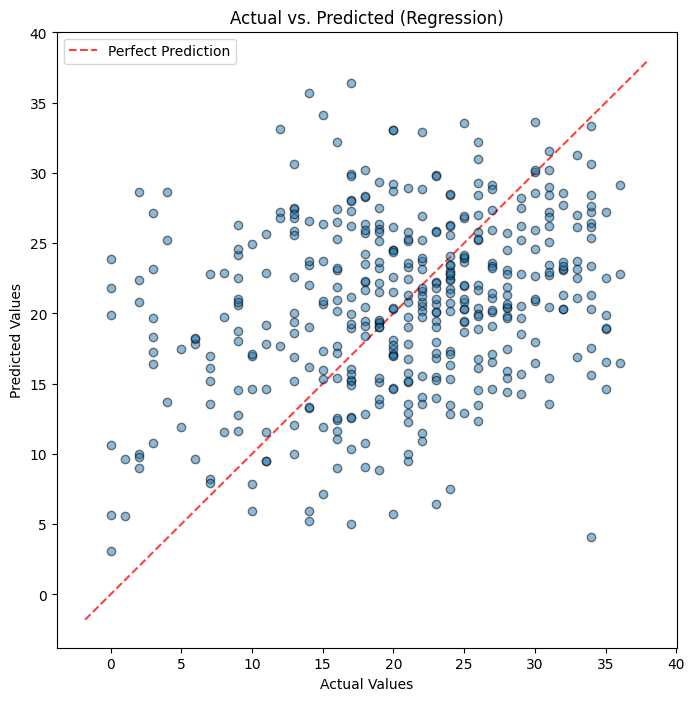

In [17]:
from src.evaluation import Evaluation

evaluation = Evaluation(prediction, actual)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
